<a href="https://colab.research.google.com/github/aiska28/Data-Maining/blob/main/labu_Polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import files
uploaded = files.upload()

Saving new-york_9-24-2016_9-30-2017.csv to new-york_9-24-2016_9-30-2017.csv


In [3]:
df = pd.read_csv('new-york_9-24-2016_9-30-2017.csv')
df.head()

,Commodity Name,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,...,Color,Environment,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode
0,PUMPKINS,NEW YORK,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,150,170,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
1,PUMPKINS,NEW YORK,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,150,170,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
2,PUMPKINS,NEW YORK,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,130,150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
3,PUMPKINS,NEW YORK,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,130,150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN
4,PUMPKINS,NEW YORK,NaN,36 inch bins,HOWDEN TYPE,NaN,NaN,09/24/2016,120,140,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN


In [4]:
X = df[['Low Price']]
y = df['High Price']

In [5]:
df = df.dropna(subset=['Low Price', 'High Price'])

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [8]:
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [9]:
y_pred = model.predict(X_test_poly)

In [10]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 129.81043527919596
R2 Score: 0.9795692840435385


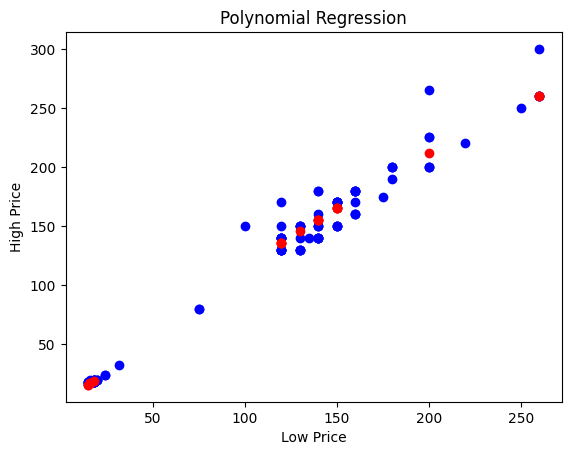

In [11]:
plt.scatter(X, y, color='blue')
plt.scatter(X_test, y_pred, color='red')
plt.xlabel('Low Price')
plt.ylabel('High Price')
plt.title('Polynomial Regression')
plt.show()